# Financial Market Analysis & Trading Strategy

## Project Overview

This project analyzes historical Bitcoin market data using Python to evaluate price performance, returns, volatility, drawdowns, and risk-adjusted performance.

The project also applies a simple 50-day and 200-day moving average crossover strategy and compares its historical performance against a traditional buy-and-hold approach.

The objective is to demonstrate how data analysis, financial risk metrics, technical indicators, and basic strategy backtesting can be combined to evaluate financial market performance.

> **Disclaimer:** This project is for educational and analytical purposes only. Historical backtest results do not guarantee future performance and do not account for transaction costs, slippage, taxes, liquidity constraints, or market impact.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## 3. Data Collection

In [2]:
# Download Bitcoin historical market data
btc = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)

btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


## 4. Data Inspection and Cleaning

In [3]:
# Check the shape of the dataset
print("Dataset shape:", btc.shape)

# Check the column names
print("\nColumns:")
print(btc.columns)

# Check the data types
print("\nData types:")
print(btc.dtypes)

# Check for missing values
print("\nMissing values:")
print(btc.isnull().sum())

Dataset shape: (2192, 5)

Columns:
MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

Data types:
Price   Ticker 
Close   BTC-USD    float64
High    BTC-USD    float64
Low     BTC-USD    float64
Open    BTC-USD    float64
Volume  BTC-USD      int64
dtype: object

Missing values:
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64


## 5. Bitcoin Price Performance

In [4]:
# Extract Bitcoin closing prices
close = btc["Close"]

# If the result is a DataFrame, convert it to a Series
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

# Display the first few closing prices
close.head()

Date
2020-01-01    7200.174316
2020-01-02    6985.470215
2020-01-03    7344.884277
2020-01-04    7410.656738
2020-01-05    7411.317383
Name: BTC-USD, dtype: float64

## 6. Daily Returns Analysis

In [5]:
# Calculate daily percentage returns
daily_returns = close.pct_change()

# Remove the first missing value
daily_returns = daily_returns.dropna()

# Display the first few returns
daily_returns.head()

Date
2020-01-02   -0.029819
2020-01-03    0.051452
2020-01-04    0.008955
2020-01-05    0.000089
2020-01-06    0.048291
Name: BTC-USD, dtype: float64

In [6]:
# Calculate performance metrics
total_return = (close.iloc[-1] / close.iloc[0]) - 1
average_daily_return = daily_returns.mean()
daily_volatility = daily_returns.std()

print(f"Total Return: {total_return:.2%}")
print(f"Average Daily Return: {average_daily_return:.4%}")
print(f"Daily Volatility: {daily_volatility:.4%}")

Total Return: 1115.37%
Average Daily Return: 0.1658%
Daily Volatility: 3.1911%


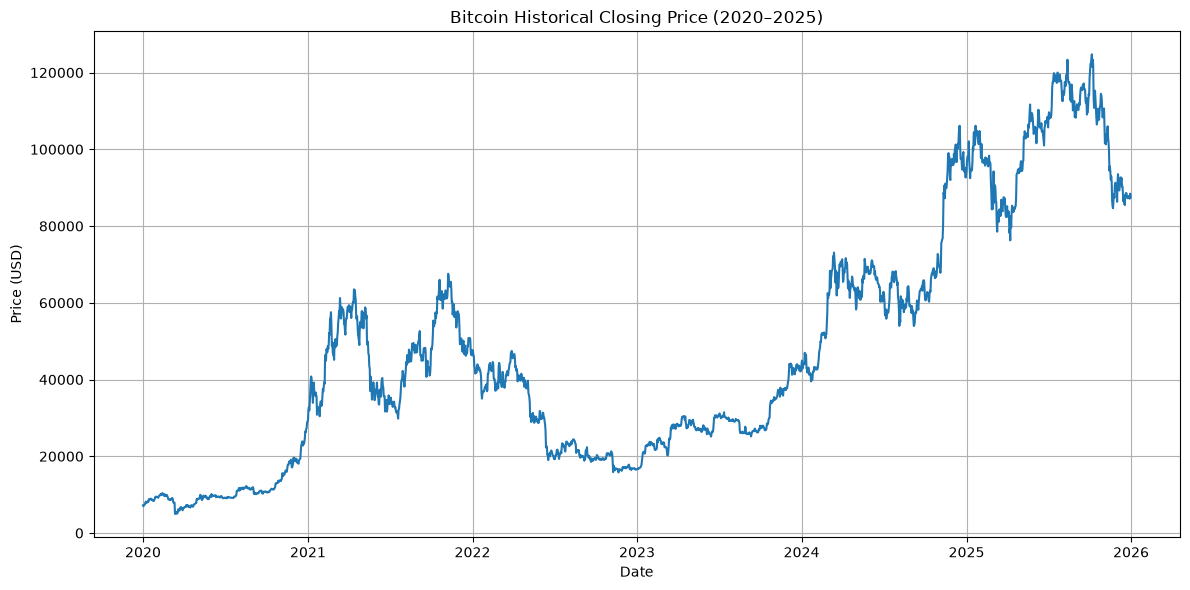

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(close)

plt.title("Bitcoin Historical Closing Price (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/bitcoin_historical_closing_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

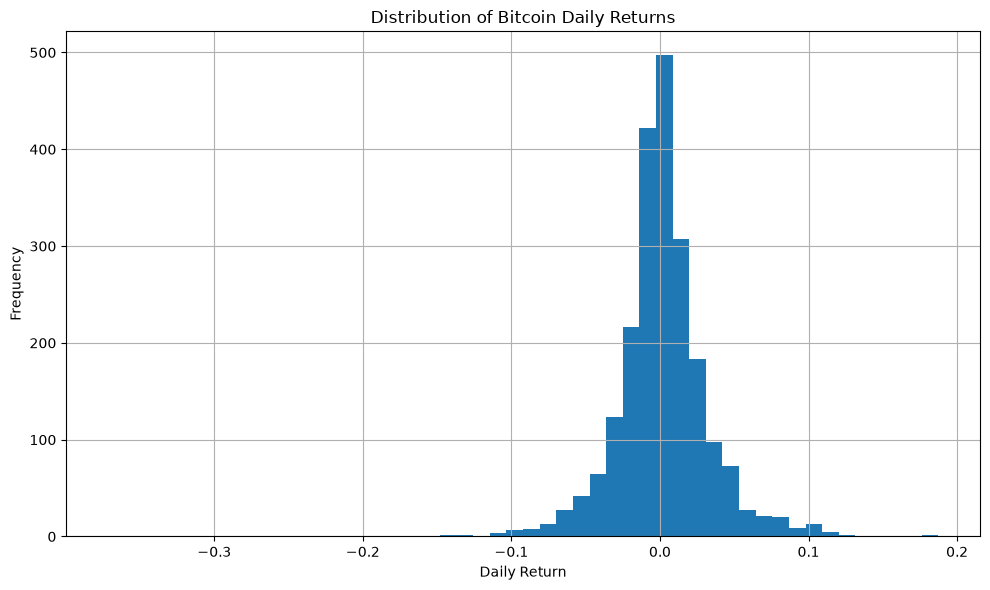

In [8]:
# Visualize the distribution of daily returns

plt.figure(figsize=(10, 6))

plt.hist(daily_returns, bins=50)

plt.title("Distribution of Bitcoin Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/bitcoin_daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Risk and Volatility Analysis

In [9]:
# Calculate annualized volatility

annualized_volatility = daily_returns.std() * np.sqrt(365)

print(f"Annualized Volatility: {annualized_volatility:.2%}")

Annualized Volatility: 60.97%


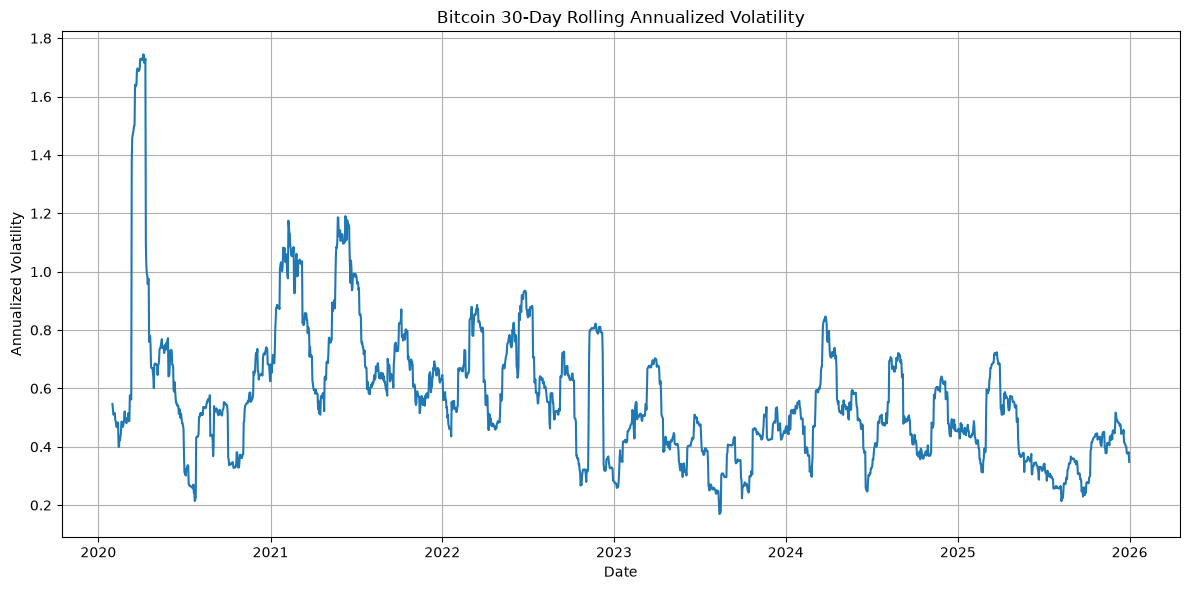

In [10]:
# Calculate 30-day rolling annualized volatility

rolling_volatility = daily_returns.rolling(window=30).std() * np.sqrt(365)

plt.figure(figsize=(12, 6))

plt.plot(rolling_volatility)

plt.title("Bitcoin 30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/bitcoin_rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Drawdown Analysis

In [11]:
# Calculate cumulative returns

cumulative_returns = (1 + daily_returns).cumprod()

# Calculate running maximum

running_max = cumulative_returns.cummax()

# Calculate drawdown

drawdown = (cumulative_returns / running_max) - 1

# Calculate maximum drawdown

max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -76.63%


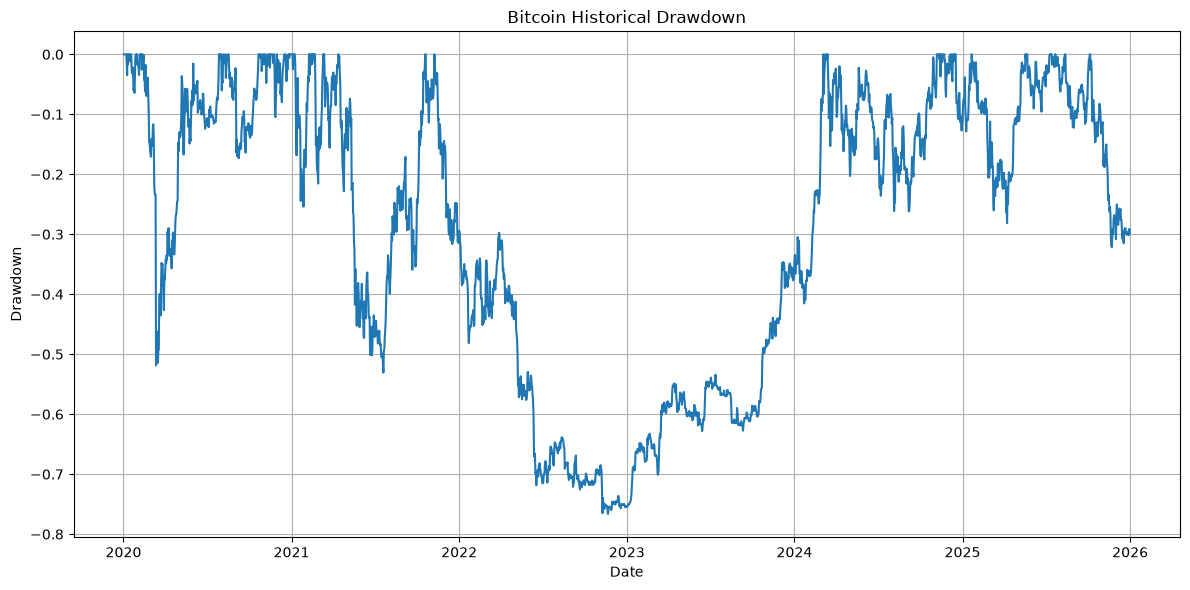

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(drawdown)

plt.title("Bitcoin Historical Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/bitcoin_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Calculate annualized return

annualized_return = daily_returns.mean() * 365

# Calculate Sharpe Ratio

sharpe_ratio = annualized_return / annualized_volatility

print(f"Annualized Return: {annualized_return:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Annualized Return: 60.53%
Sharpe Ratio: 0.99


## 9. Technical Analysis

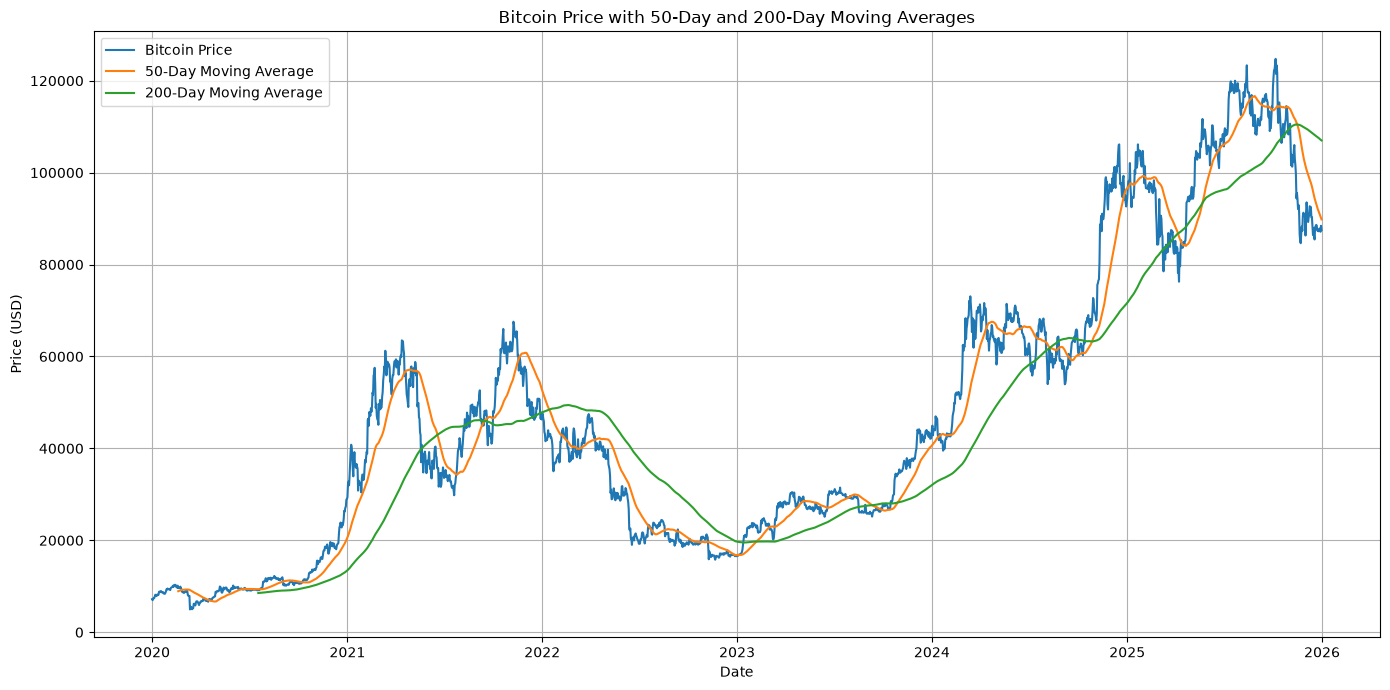

In [14]:
# Calculate moving averages

ma_50 = close.rolling(window=50).mean()
ma_200 = close.rolling(window=200).mean()

# Plot Bitcoin price and moving averages

plt.figure(figsize=(14, 7))

plt.plot(close, label="Bitcoin Price")
plt.plot(ma_50, label="50-Day Moving Average")
plt.plot(ma_200, label="200-Day Moving Average")

plt.title("Bitcoin Price with 50-Day and 200-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/bitcoin_moving_averages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Moving Average Crossover Strategy

In [15]:
# Create a DataFrame for moving average analysis

ma_data = pd.DataFrame({
    "Close": close,
    "MA50": ma_50,
    "MA200": ma_200
}).dropna()

# Identify crossover signals

ma_data["Signal"] = 0

# Golden Cross
ma_data.loc[
    (ma_data["MA50"] > ma_data["MA200"]) &
    (ma_data["MA50"].shift(1) <= ma_data["MA200"].shift(1)),
    "Signal"
] = 1

# Death Cross
ma_data.loc[
    (ma_data["MA50"] < ma_data["MA200"]) &
    (ma_data["MA50"].shift(1) >= ma_data["MA200"].shift(1)),
    "Signal"
] = -1

# Display crossover events

crossovers = ma_data[ma_data["Signal"] != 0]

print(crossovers)

                    Close           MA50          MA200  Signal
Date                                                           
2021-06-19   35615.871094   42860.275234   43005.147021      -1
2021-09-15   48176.347656   45981.039219   45921.771230       1
2022-01-14   43099.699219   48422.467344   48442.347363      -1
2023-02-07   23264.291016   19835.039414   19730.518096       1
2023-09-12   25833.343750   27565.313828   27641.025371      -1
2023-10-30   34502.363281   28361.811641   28249.226377       1
2024-08-10   60945.812500   61938.341094   61988.867500      -1
2024-10-28   69907.757812   63548.888594   63262.153320       1
2025-04-07   79235.335938   86434.996406   86814.515410      -1
2025-05-22  111673.281250   93482.528594   93409.423125       1
2025-11-16   94177.078125  110322.305938  110473.041797      -1


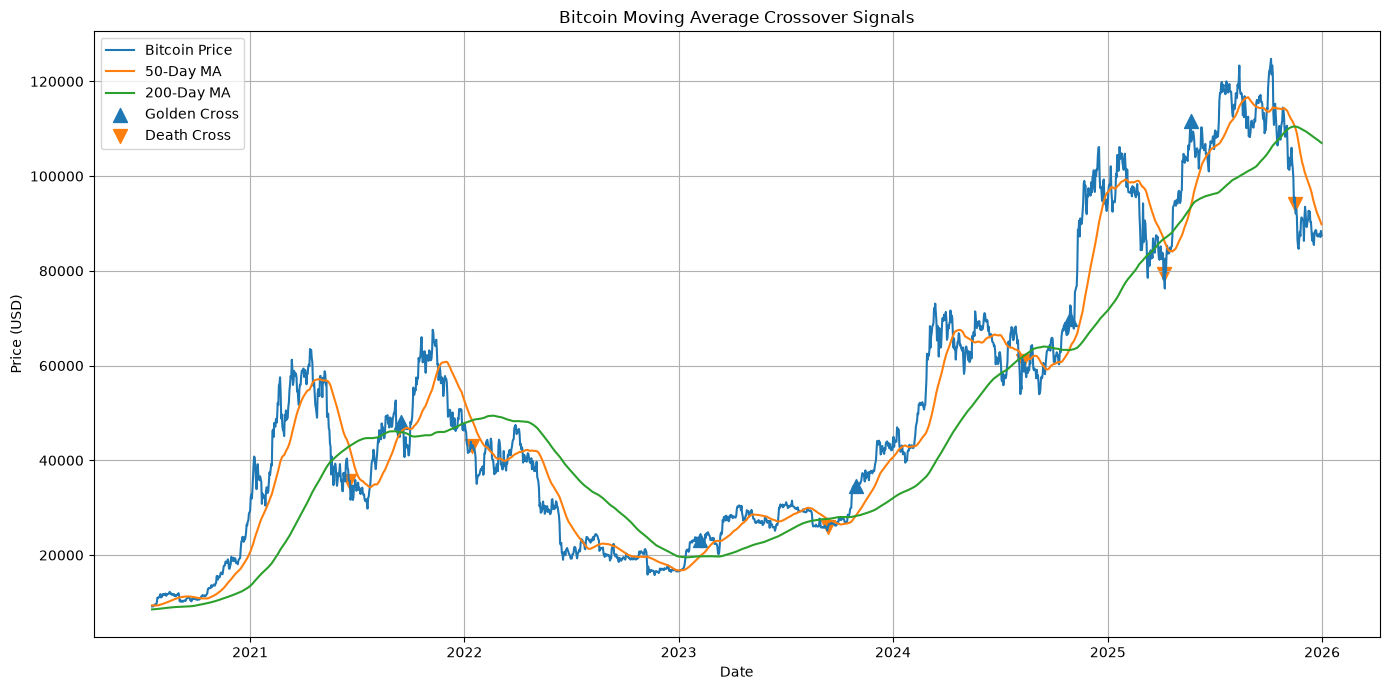

In [16]:
# Plot price and moving averages

plt.figure(figsize=(14, 7))

plt.plot(
    ma_data.index,
    ma_data["Close"],
    label="Bitcoin Price"
)

plt.plot(
    ma_data.index,
    ma_data["MA50"],
    label="50-Day MA"
)

plt.plot(
    ma_data.index,
    ma_data["MA200"],
    label="200-Day MA"
)

# Plot Golden Cross signals

golden_cross = ma_data[ma_data["Signal"] == 1]

plt.scatter(
    golden_cross.index,
    golden_cross["Close"],
    marker="^",
    s=100,
    label="Golden Cross"
)

# Plot Death Cross signals

death_cross = ma_data[ma_data["Signal"] == -1]

plt.scatter(
    death_cross.index,
    death_cross["Close"],
    marker="v",
    s=100,
    label="Death Cross"
)

plt.title("Bitcoin Moving Average Crossover Signals")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/bitcoin_moving_average_crossovers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Strategy Performance Evaluation

In [17]:
# Create trading position

ma_data["Position"] = np.where(
    ma_data["MA50"] > ma_data["MA200"],
    1,
    0
)

# Calculate daily market returns

ma_data["Market_Return"] = ma_data["Close"].pct_change()

# Calculate strategy returns
# Shift position by one day to avoid look-ahead bias

ma_data["Strategy_Return"] = (
    ma_data["Position"].shift(1) *
    ma_data["Market_Return"]
)

# Remove missing values

ma_data = ma_data.dropna()

# Display the results

ma_data[[
    "Close",
    "MA50",
    "MA200",
    "Position",
    "Market_Return",
    "Strategy_Return"
]].head()

,Close,MA50,MA200,Position,Market_Return,Strategy_Return
Date,,,,,,
2020-07-19,9185.817383,9384.423887,8544.059065,1,0.002924,0.002924
2020-07-20,9164.231445,9378.487344,8554.952871,1,-0.002350,-0.002350
2020-07-21,9374.887695,9362.639727,8565.102888,1,0.022987,0.022987
2020-07-22,9525.363281,9362.550918,8575.676421,1,0.016051,0.016051
2020-07-23,9581.072266,9361.038008,8586.525195,1,0.005848,0.005848


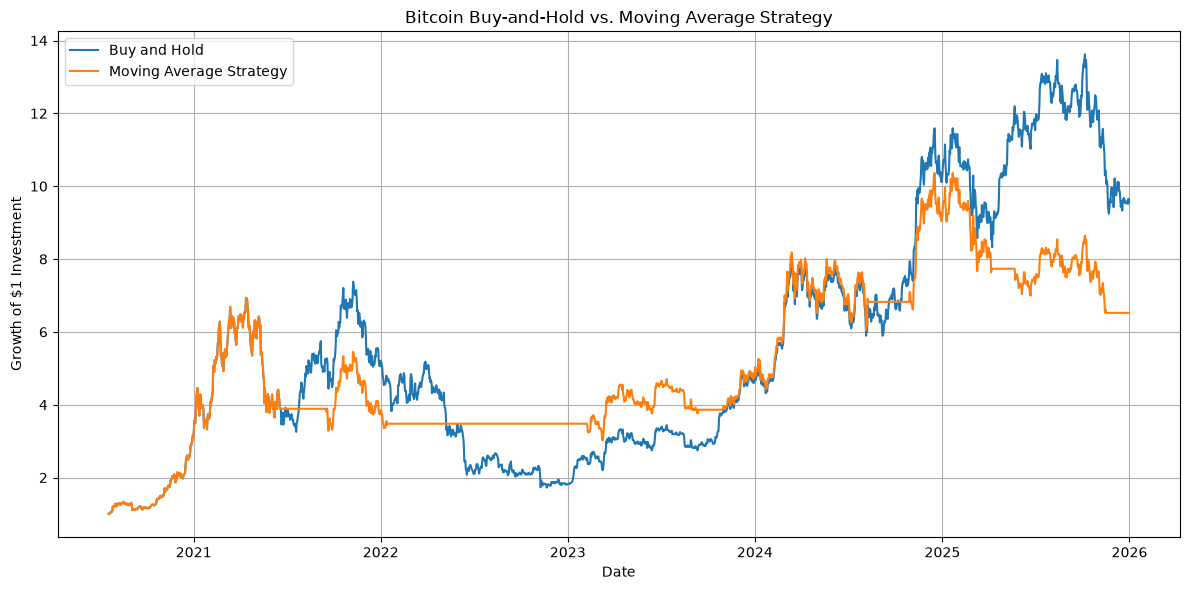

In [18]:
# Calculate cumulative performance

ma_data["Buy_Hold_Cumulative"] = (
    1 + ma_data["Market_Return"]
).cumprod()

ma_data["Strategy_Cumulative"] = (
    1 + ma_data["Strategy_Return"]
).cumprod()

# Plot performance comparison

plt.figure(figsize=(12, 6))

plt.plot(
    ma_data.index,
    ma_data["Buy_Hold_Cumulative"],
    label="Buy and Hold"
)

plt.plot(
    ma_data.index,
    ma_data["Strategy_Cumulative"],
    label="Moving Average Strategy"
)

plt.title("Bitcoin Buy-and-Hold vs. Moving Average Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/bitcoin_strategy_vs_buy_and_hold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# Calculate total returns

buy_hold_return = (
    ma_data["Buy_Hold_Cumulative"].iloc[-1] - 1
)

strategy_return = (
    ma_data["Strategy_Cumulative"].iloc[-1] - 1
)

print(f"Buy-and-Hold Return: {buy_hold_return:.2%}")
print(f"Moving Average Strategy Return: {strategy_return:.2%}")

Buy-and-Hold Return: 855.44%
Moving Average Strategy Return: 552.24%


In [20]:
# Calculate annualized strategy volatility

strategy_volatility = (
    ma_data["Strategy_Return"].std() *
    np.sqrt(365)
)

# Calculate annualized strategy return

strategy_annualized_return = (
    ma_data["Strategy_Return"].mean() *
    365
)

# Calculate strategy Sharpe Ratio

strategy_sharpe = (
    strategy_annualized_return /
    strategy_volatility
)

print(f"Strategy Annualized Return: {strategy_annualized_return:.2%}")
print(f"Strategy Annualized Volatility: {strategy_volatility:.2%}")
print(f"Strategy Sharpe Ratio: {strategy_sharpe:.2f}")

Strategy Annualized Return: 45.44%
Strategy Annualized Volatility: 47.22%
Strategy Sharpe Ratio: 0.96


In [21]:
# Calculate strategy running maximum

strategy_running_max = (
    ma_data["Strategy_Cumulative"].cummax()
)

# Calculate strategy drawdown

strategy_drawdown = (
    ma_data["Strategy_Cumulative"] /
    strategy_running_max
) - 1

# Calculate maximum drawdown

strategy_max_drawdown = strategy_drawdown.min()

print(
    f"Strategy Maximum Drawdown: "
    f"{strategy_max_drawdown:.2%}"
)

Strategy Maximum Drawdown: -56.46%


## 12. Buy-and-Hold vs. Trading Strategy

In [22]:
# Create a performance summary

performance_summary = pd.DataFrame({
    "Strategy": [
        "Buy and Hold",
        "Moving Average Strategy"
    ],
    "Total Return": [
        buy_hold_return,
        strategy_return
    ],
    "Annualized Volatility": [
        daily_returns.std() * np.sqrt(365),
        strategy_volatility
    ],
    "Maximum Drawdown": [
        max_drawdown,
        strategy_max_drawdown
    ],
    "Sharpe Ratio": [
        sharpe_ratio,
        strategy_sharpe
    ]
})

performance_summary

,Strategy,Total Return,Annualized Volatility,Maximum Drawdown,Sharpe Ratio
0,Buy and Hold,8.554367,0.609654,-0.766346,0.992891
1,Moving Average Strategy,5.522428,0.472237,-0.564615,0.962283


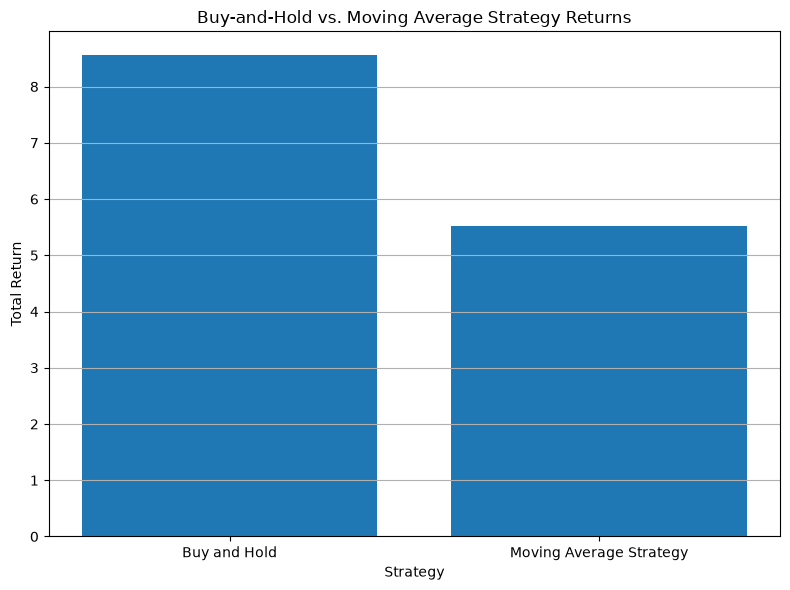

In [23]:
# Compare total returns

plt.figure(figsize=(8, 6))

plt.bar(
    performance_summary["Strategy"],
    performance_summary["Total Return"]
)

plt.title("Buy-and-Hold vs. Moving Average Strategy Returns")
plt.xlabel("Strategy")
plt.ylabel("Total Return")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "images/strategy_return_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

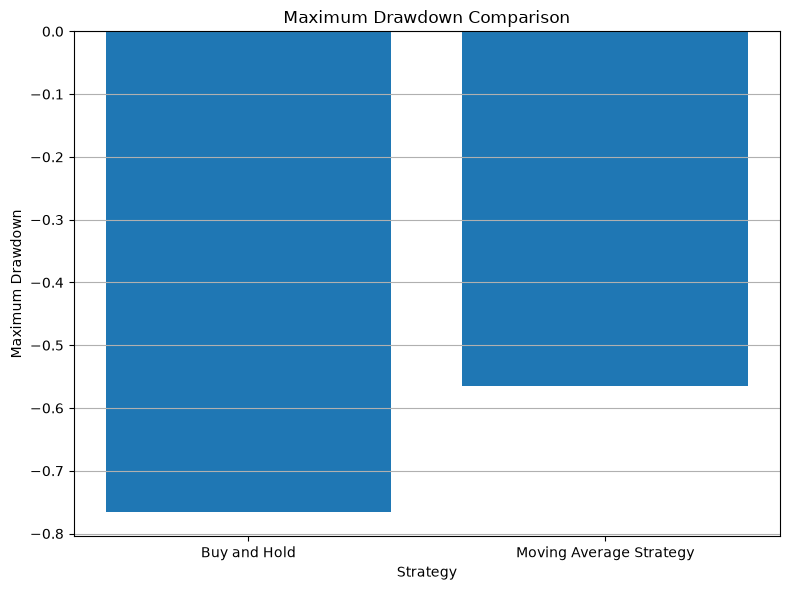

In [24]:
# Compare maximum drawdown

plt.figure(figsize=(8, 6))

plt.bar(
    performance_summary["Strategy"],
    performance_summary["Maximum Drawdown"]
)

plt.title("Maximum Drawdown Comparison")
plt.xlabel("Strategy")
plt.ylabel("Maximum Drawdown")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "images/maximum_drawdown_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

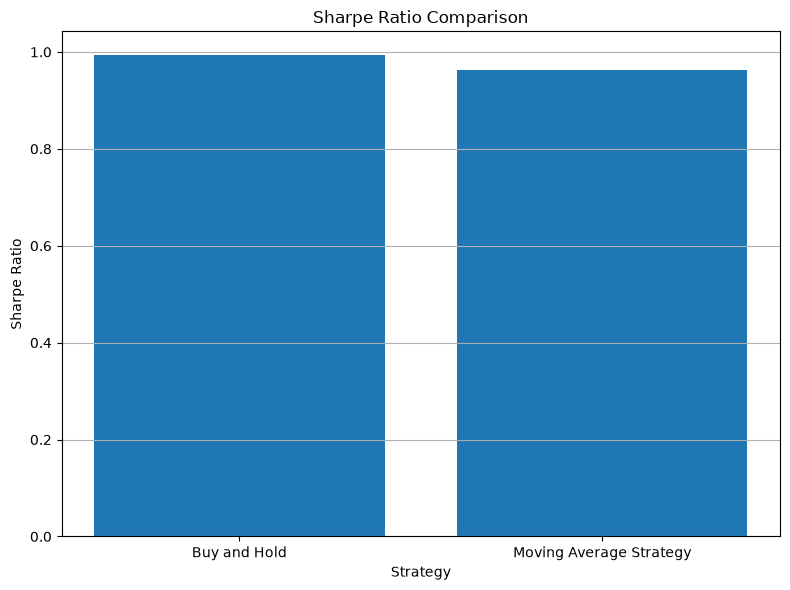

In [25]:
# Compare Sharpe Ratios

plt.figure(figsize=(8, 6))

plt.bar(
    performance_summary["Strategy"],
    performance_summary["Sharpe Ratio"]
)

plt.title("Sharpe Ratio Comparison")
plt.xlabel("Strategy")
plt.ylabel("Sharpe Ratio")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "images/sharpe_ratio_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Key Findings

The analysis of Bitcoin's historical market performance between 2020 and 2025 produced several important findings:

- Bitcoin generated a strong historical total return of approximately **855.44%** through a buy-and-hold approach during the analysis period.
- The buy-and-hold approach experienced substantial risk, with annualized volatility of approximately **60.97%** and a maximum drawdown of approximately **-76.63%**.
- The moving average crossover strategy generated a historical total return of approximately **552.24%**, which was lower than the buy-and-hold approach.
- The moving average strategy reduced annualized volatility to approximately **47.22%**, compared with **60.97%** for buy-and-hold.
- The moving average strategy also reduced maximum drawdown to approximately **-56.46%**, compared with **-76.63%** for buy-and-hold.
- The buy-and-hold approach achieved a Sharpe Ratio of approximately **0.99**, while the moving average strategy achieved approximately **0.96**.
- The results suggest that the moving average strategy provided lower downside risk and lower volatility but did not outperform the buy-and-hold approach in terms of total return or Sharpe Ratio during the analysis period.
- These findings demonstrate the importance of evaluating both returns and risk when analyzing investment strategies rather than focusing solely on total profitability.

## 14. Conclusion

This project demonstrates an end-to-end approach to financial market analysis using Python.

The analysis progressed from historical Bitcoin price data and daily return calculations to volatility analysis, drawdown measurement, technical indicators, and trading strategy evaluation.

The results show that the buy-and-hold approach generated a higher historical return during the analysis period, while the moving average crossover strategy provided lower volatility and reduced maximum drawdown. This highlights the trade-off between maximizing returns and managing downside risk.

Although the moving average strategy did not outperform buy-and-hold in terms of total return or Sharpe Ratio during the period analyzed, it demonstrated the potential to reduce exposure to market declines and overall portfolio volatility.

The analysis also demonstrates the importance of evaluating investment strategies using multiple performance metrics, including total return, volatility, maximum drawdown, and Sharpe Ratio.

> **Disclaimer:** This project is for educational and analytical purposes only. Historical backtest results do not guarantee future performance. The strategy does not account for transaction costs, slippage, taxes, liquidity constraints, or market impact, all of which may significantly affect real-world trading performance.